In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load Balancer Benchmark Analysis

Comparing performance across three configurations:
- **py** — Python server (direct)
- **lb** — Load Balancer (with rate limiting)
- **lbwrl** — Load Balancer without rate limiting

Metrics analyzed:
1. Throughput (requests/sec)
2. Latency percentiles (p50–p100)
3. Success vs failure rates
4. Scalability under increasing load
5. Transfer rates
6. Latency consistency / jitter

In [25]:
# Load and prepare data
df = pd.read_csv("benchmark_results.csv")
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Friendly labels for tags
tag_labels = {'py': 'Python Server', 'lb': 'Load Balancer', 'lbwrl': 'LB (no rate limit)'}
df['label'] = df['tag'].map(tag_labels)

# Separate successful and failed runs
df_success = df[df['status'] == 'success'].copy()
df_failed = df[df['status'] == 'failed'].copy()

print(f"Total runs: {len(df)}")
print(f"Successful: {len(df_success)}")
print(f"Failed: {len(df_failed)}")
print(f"\nRuns per tag:")
print(df.groupby(['tag', 'status']).size().unstack(fill_value=0))
print(f"\nConcurrency levels tested: {sorted(df['concurrency'].unique())}")
print(f"Total requests range: {df['total_requests'].min():,} – {df['total_requests'].max():,}")

Total runs: 50
Successful: 35
Failed: 15

Runs per tag:
status  failed  success
tag                    
lb           6       19
lbwrl        0        7
py           9        9

Concurrency levels tested: [np.int64(1), np.int64(10), np.int64(100), np.int64(500), np.int64(700), np.int64(1000), np.int64(1020), np.int64(1021), np.int64(1023), np.int64(1024), np.int64(1050), np.int64(1100), np.int64(1200), np.int64(1500), np.int64(2000)]
Total requests range: 5,000 – 1,000,000


## 1. Success / Failure Rate by Tag
How reliable is each configuration under stress?

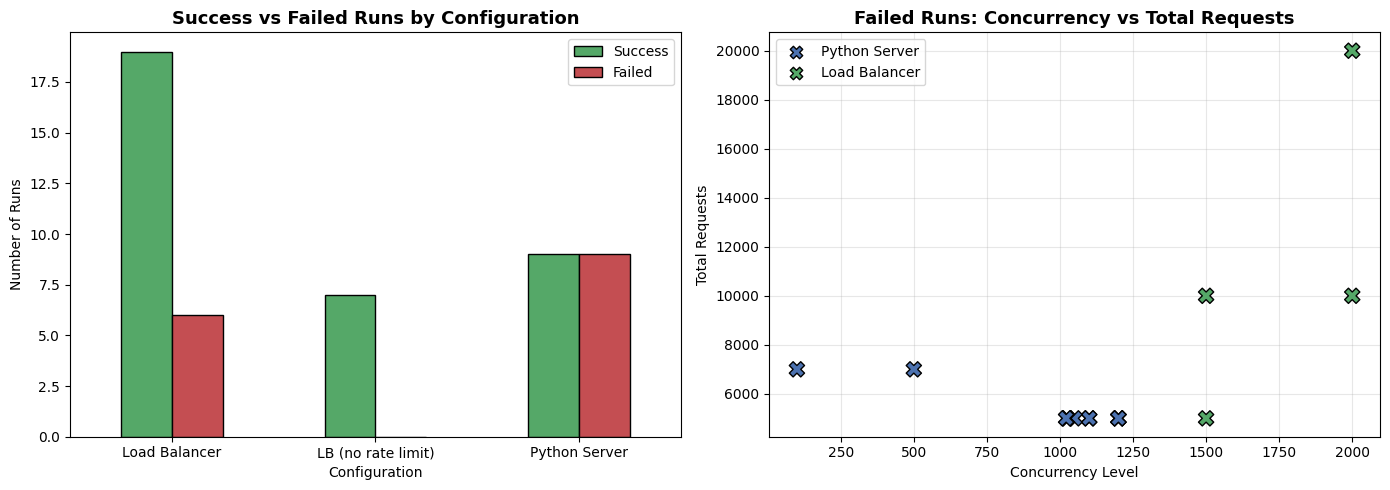

In [26]:
# Success / Failure counts
palette = {'py': '#4C72B0', 'lb': '#55A868', 'lbwrl': '#C44E52'}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Count of success vs failure per tag
status_counts = df.groupby(['tag', 'status']).size().unstack(fill_value=0)
status_counts = status_counts.reindex(columns=['success', 'failed'], fill_value=0)
status_counts.plot(kind='bar', ax=axes[0], color=['#55A868', '#C44E52'], edgecolor='black')
axes[0].set_title('Success vs Failed Runs by Configuration', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('Number of Runs')
axes[0].set_xticklabels([tag_labels.get(t, t) for t in status_counts.index], rotation=0)
axes[0].legend(['Success', 'Failed'])

# Show what concurrency/request levels caused failures
if len(df_failed) > 0:
    fail_info = df_failed[['tag', 'total_requests', 'concurrency']].copy()
    fail_info['label'] = fail_info['tag'].map(tag_labels)
    axes[1].scatter(fail_info['concurrency'], fail_info['total_requests'],
                    c=fail_info['tag'].map(palette), s=120, edgecolors='black', zorder=5, marker='X')
    axes[1].set_title('Failed Runs: Concurrency vs Total Requests', fontsize=13, fontweight='bold')
    axes[1].set_xlabel('Concurrency Level')
    axes[1].set_ylabel('Total Requests')
    # Add legend
    for tag, color in palette.items():
        if tag in fail_info['tag'].values:
            axes[1].scatter([], [], c=color, s=80, marker='X', label=tag_labels[tag], edgecolors='black')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 2. Throughput Comparison (Requests/sec)
Peak and average throughput across successful runs for each configuration.

/tmp/ipykernel_316474/1573665304.py:29: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(data_for_box, labels=[tag_labels[t] for t in ['py', 'lb', 'lbwrl']],


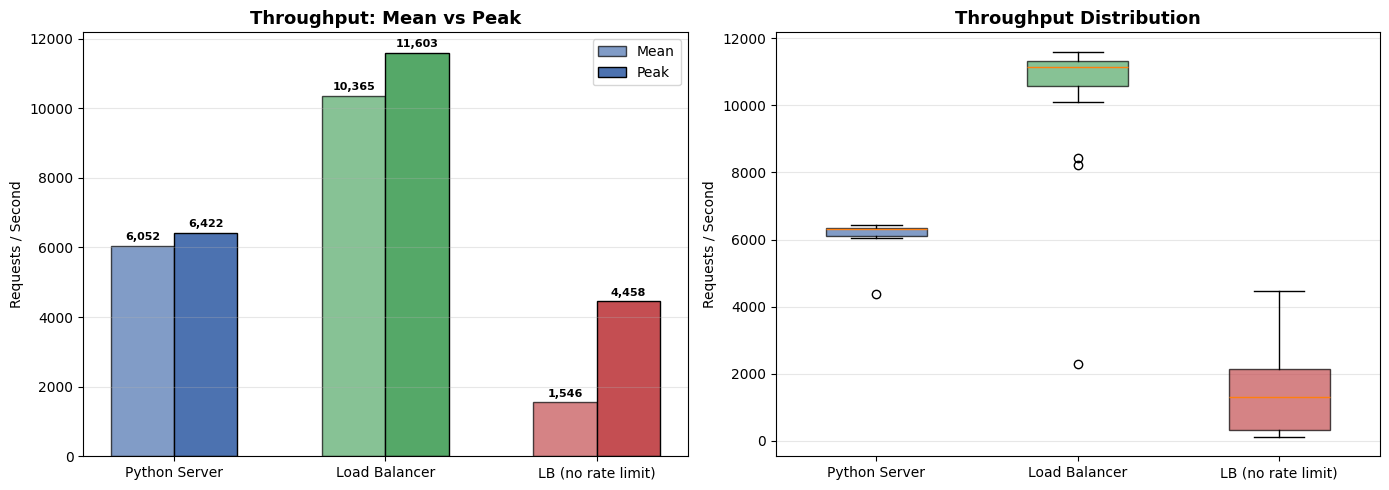


Throughput Summary (successful runs only):

Python Server:
  Mean:    6,052.4 req/s
  Peak:    6,421.7 req/s
  Min:     4,368.8 req/s

Load Balancer:
  Mean:   10,364.7 req/s
  Peak:   11,603.0 req/s
  Min:     2,276.2 req/s

LB (no rate limit):
  Mean:    1,546.1 req/s
  Peak:    4,458.1 req/s
  Min:       112.2 req/s


In [27]:
# Throughput comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Bar chart: avg and max throughput per tag
throughput_stats = df_success.groupby('tag')['requests_per_second'].agg(['mean', 'max', 'min', 'std'])
throughput_stats = throughput_stats.reindex(['py', 'lb', 'lbwrl'])
x = np.arange(len(throughput_stats))
width = 0.3

bars1 = axes[0].bar(x - width/2, throughput_stats['mean'], width, label='Mean', 
                     color=[palette[t] for t in throughput_stats.index], edgecolor='black', alpha=0.7)
bars2 = axes[0].bar(x + width/2, throughput_stats['max'], width, label='Peak',
                     color=[palette[t] for t in throughput_stats.index], edgecolor='black', alpha=1.0)
axes[0].set_xticks(x)
axes[0].set_xticklabels([tag_labels[t] for t in throughput_stats.index])
axes[0].set_ylabel('Requests / Second')
axes[0].set_title('Throughput: Mean vs Peak', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Add value labels on bars
for bar in list(bars1) + list(bars2):
    h = bar.get_height()
    axes[0].text(bar.get_x() + bar.get_width()/2., h + 100, f'{h:,.0f}',
                 ha='center', va='bottom', fontsize=8, fontweight='bold')

# Box plot of throughput distribution
data_for_box = [df_success[df_success['tag'] == t]['requests_per_second'].values for t in ['py', 'lb', 'lbwrl']]
bp = axes[1].boxplot(data_for_box, labels=[tag_labels[t] for t in ['py', 'lb', 'lbwrl']], 
                      patch_artist=True, widths=0.5)
for patch, tag in zip(bp['boxes'], ['py', 'lb', 'lbwrl']):
    patch.set_facecolor(palette[tag])
    patch.set_alpha(0.7)
axes[1].set_ylabel('Requests / Second')
axes[1].set_title('Throughput Distribution', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

# Print summary table
print("\nThroughput Summary (successful runs only):")
print("=" * 65)
for tag in ['py', 'lb', 'lbwrl']:
    subset = df_success[df_success['tag'] == tag]
    print(f"\n{tag_labels[tag]}:")
    print(f"  Mean: {subset['requests_per_second'].mean():>10,.1f} req/s")
    print(f"  Peak: {subset['requests_per_second'].max():>10,.1f} req/s")
    print(f"  Min:  {subset['requests_per_second'].min():>10,.1f} req/s")

## 3. Latency Percentile Comparison
How does response time vary across percentiles for each configuration? Lower is better.

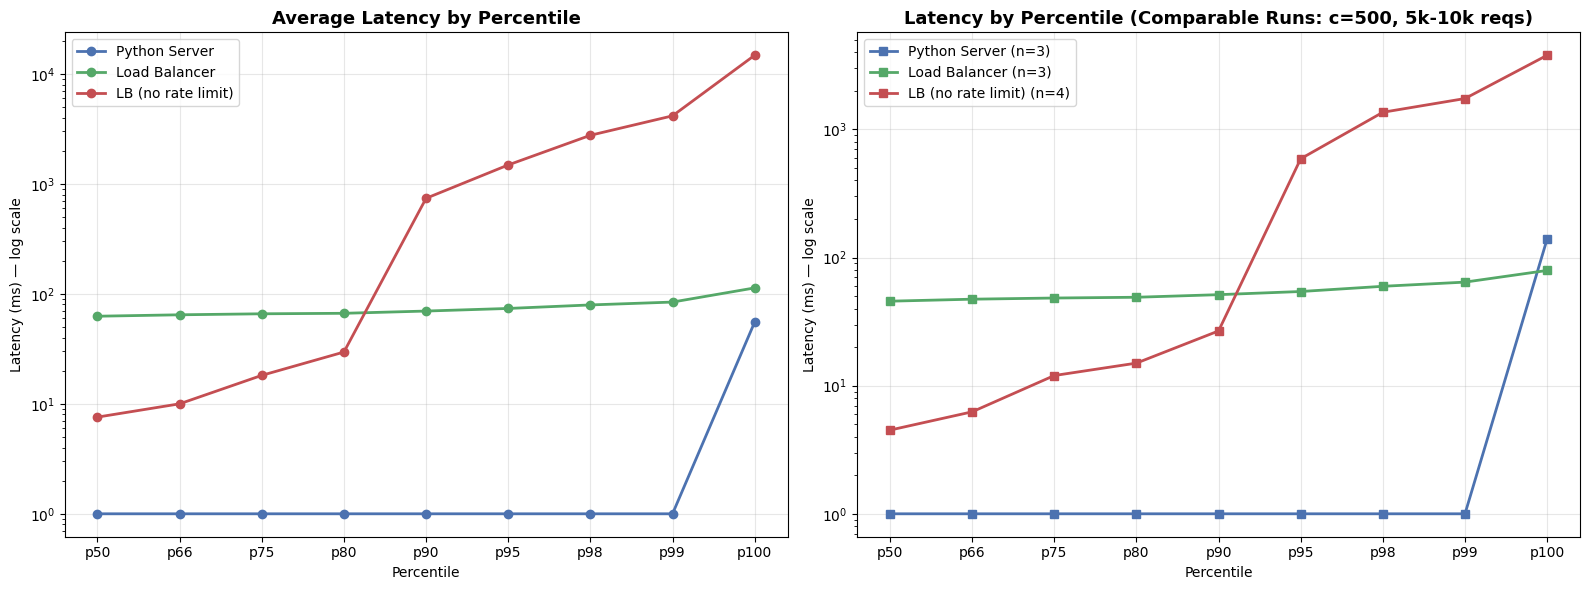

In [28]:
# Latency percentile comparison — average across successful runs
percentile_cols = ['p50_ms', 'p66_ms', 'p75_ms', 'p80_ms', 'p90_ms', 'p95_ms', 'p98_ms', 'p99_ms', 'p100_ms']
percentile_labels = ['p50', 'p66', 'p75', 'p80', 'p90', 'p95', 'p98', 'p99', 'p100']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: line chart of average latency at each percentile
for tag in ['py', 'lb', 'lbwrl']:
    subset = df_success[df_success['tag'] == tag]
    avg_latencies = subset[percentile_cols].mean()
    axes[0].plot(percentile_labels, avg_latencies, marker='o', linewidth=2, markersize=6,
                 label=tag_labels[tag], color=palette[tag])

axes[0].set_xlabel('Percentile')
axes[0].set_ylabel('Latency (ms)')
axes[0].set_title('Average Latency by Percentile', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')
axes[0].set_ylabel('Latency (ms) — log scale')

# Right: same but focused on comparable runs (concurrency=500, ~5000-10000 requests)
comparable = df_success[
    (df_success['concurrency'] == 500) & 
    (df_success['total_requests'].between(5000, 10000))
]

for tag in ['py', 'lb', 'lbwrl']:
    subset = comparable[comparable['tag'] == tag]
    if len(subset) > 0:
        avg_latencies = subset[percentile_cols].mean()
        axes[1].plot(percentile_labels, avg_latencies, marker='s', linewidth=2, markersize=6,
                     label=f"{tag_labels[tag]} (n={len(subset)})", color=palette[tag])

axes[1].set_xlabel('Percentile')
axes[1].set_ylabel('Latency (ms) — log scale')
axes[1].set_title('Latency by Percentile (Comparable Runs: c=500, 5k-10k reqs)', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

## 4. Scalability: Throughput vs Total Requests
How does throughput hold up as the number of total requests increases? (Successful runs only)

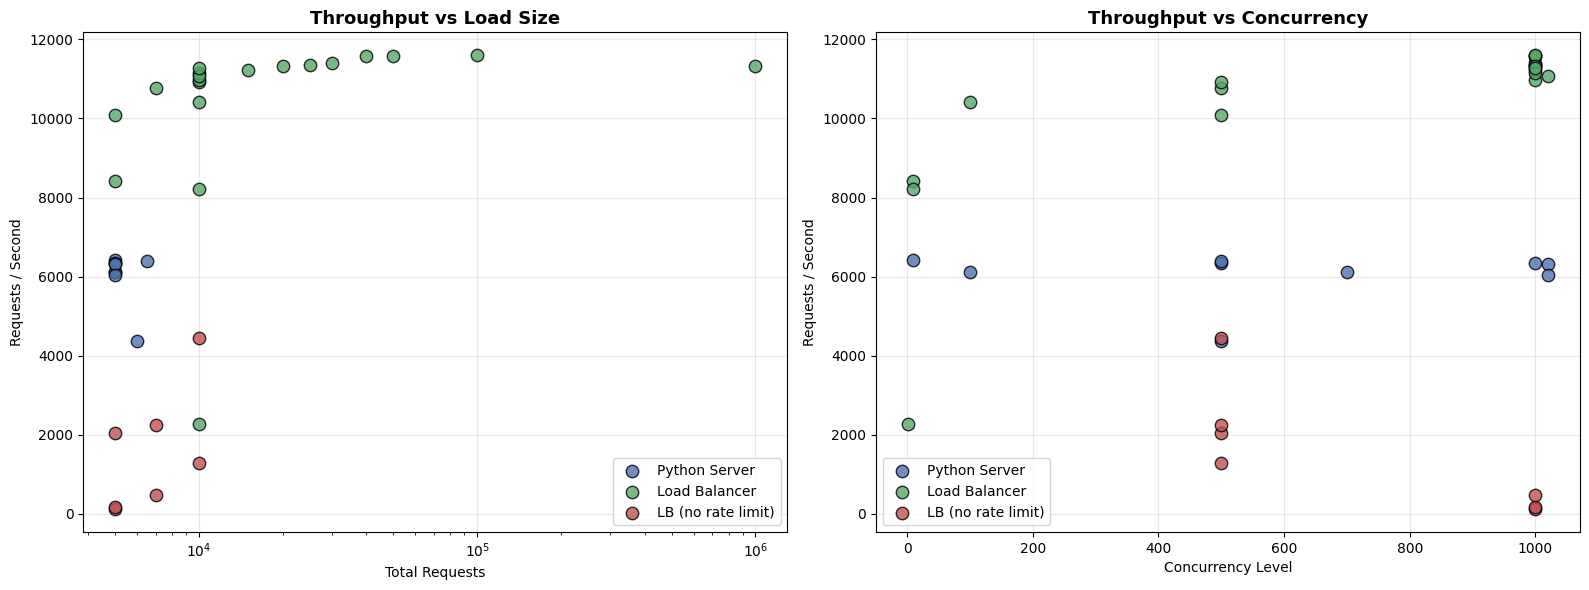

In [29]:
# Scalability: Throughput vs Total Requests
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: throughput vs total_requests scatter
for tag in ['py', 'lb', 'lbwrl']:
    subset = df_success[df_success['tag'] == tag]
    axes[0].scatter(subset['total_requests'], subset['requests_per_second'],
                    c=palette[tag], s=80, alpha=0.8, edgecolors='black', label=tag_labels[tag], zorder=5)

axes[0].set_xlabel('Total Requests')
axes[0].set_ylabel('Requests / Second')
axes[0].set_title('Throughput vs Load Size', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[0].set_xscale('log')

# Right: throughput vs concurrency
for tag in ['py', 'lb', 'lbwrl']:
    subset = df_success[df_success['tag'] == tag]
    axes[1].scatter(subset['concurrency'], subset['requests_per_second'],
                    c=palette[tag], s=80, alpha=0.8, edgecolors='black', label=tag_labels[tag], zorder=5)

axes[1].set_xlabel('Concurrency Level')
axes[1].set_ylabel('Requests / Second')
axes[1].set_title('Throughput vs Concurrency', fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 5. Mean Latency & Transfer Rate Comparison
Side-by-side comparison of average response time and data throughput.

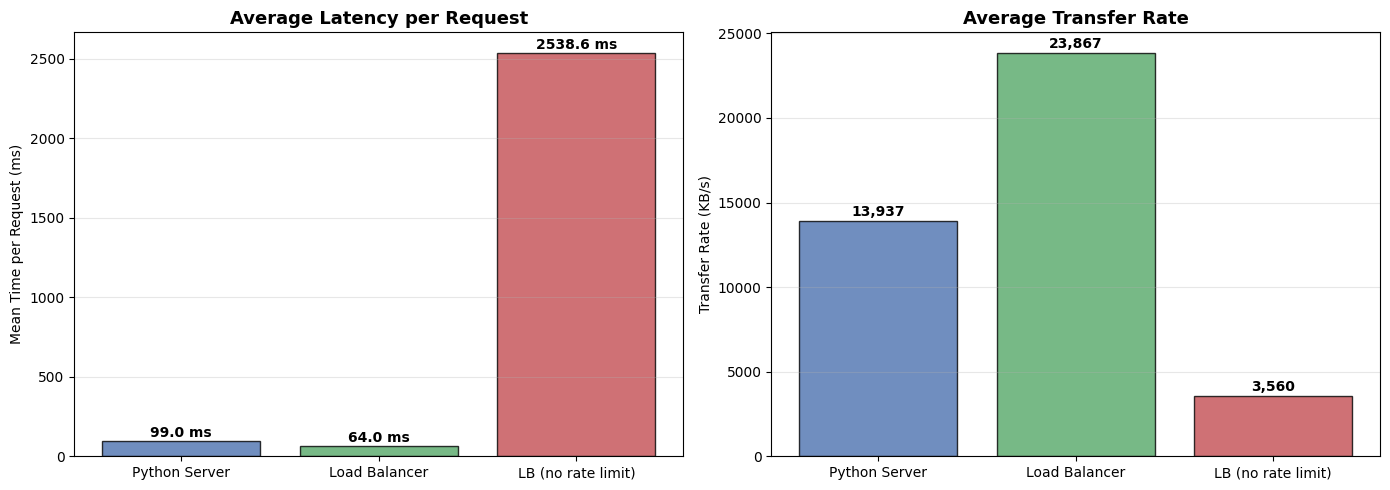

In [30]:
# Mean latency and transfer rate comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

tags_ordered = ['py', 'lb', 'lbwrl']

# Mean latency (time_per_request_mean_ms)
mean_latency = [df_success[df_success['tag'] == t]['time_per_request_mean_ms'].mean() for t in tags_ordered]
bars = axes[0].bar([tag_labels[t] for t in tags_ordered], mean_latency,
                    color=[palette[t] for t in tags_ordered], edgecolor='black', alpha=0.8)
axes[0].set_ylabel('Mean Time per Request (ms)')
axes[0].set_title('Average Latency per Request', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, mean_latency):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5,
                 f'{val:.1f} ms', ha='center', va='bottom', fontweight='bold')

# Transfer rate
mean_transfer = [df_success[df_success['tag'] == t]['transfer_rate_kbps'].mean() for t in tags_ordered]
bars = axes[1].bar([tag_labels[t] for t in tags_ordered], mean_transfer,
                    color=[palette[t] for t in tags_ordered], edgecolor='black', alpha=0.8)
axes[1].set_ylabel('Transfer Rate (KB/s)')
axes[1].set_title('Average Transfer Rate', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)
for bar, val in zip(bars, mean_transfer):
    axes[1].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
                 f'{val:,.0f}', ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

## 6. Tail Latency & Consistency (Jitter Analysis)
Tail latency (p99, p100) and latency spread (p100 − p50) indicate how predictable response times are.

/tmp/ipykernel_316474/1298805168.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(p99_vals, labels=[tag_labels[t] for t in tags_ordered],
/tmp/ipykernel_316474/1298805168.py:19: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[1].boxplot(p100_vals, labels=[tag_labels[t] for t in tags_ordered],


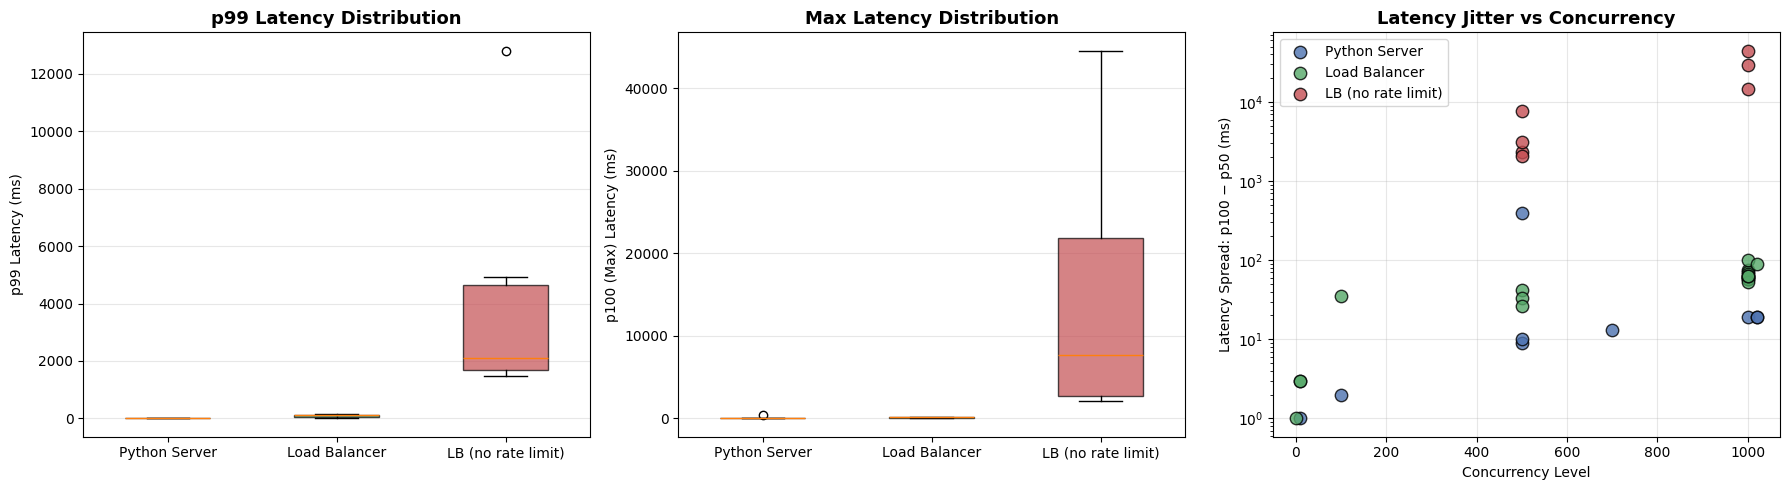

In [31]:
# Tail latency and jitter
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

tags_ordered = ['py', 'lb', 'lbwrl']

# p99 latency comparison
p99_vals = [df_success[df_success['tag'] == t]['p99_ms'].values for t in tags_ordered]
bp = axes[0].boxplot(p99_vals, labels=[tag_labels[t] for t in tags_ordered], 
                      patch_artist=True, widths=0.5)
for patch, tag in zip(bp['boxes'], tags_ordered):
    patch.set_facecolor(palette[tag])
    patch.set_alpha(0.7)
axes[0].set_ylabel('p99 Latency (ms)')
axes[0].set_title('p99 Latency Distribution', fontsize=13, fontweight='bold')
axes[0].grid(axis='y', alpha=0.3)

# p100 (max) latency comparison
p100_vals = [df_success[df_success['tag'] == t]['p100_ms'].values for t in tags_ordered]
bp = axes[1].boxplot(p100_vals, labels=[tag_labels[t] for t in tags_ordered], 
                      patch_artist=True, widths=0.5)
for patch, tag in zip(bp['boxes'], tags_ordered):
    patch.set_facecolor(palette[tag])
    patch.set_alpha(0.7)
axes[1].set_ylabel('p100 (Max) Latency (ms)')
axes[1].set_title('Max Latency Distribution', fontsize=13, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

# Jitter: p100 - p50 (latency spread)
for tag in tags_ordered:
    subset = df_success[df_success['tag'] == tag].copy()
    subset['jitter'] = subset['p100_ms'] - subset['p50_ms']
    axes[2].scatter(subset['concurrency'], subset['jitter'],
                    c=palette[tag], s=80, alpha=0.8, edgecolors='black', 
                    label=tag_labels[tag], zorder=5)

axes[2].set_xlabel('Concurrency Level')
axes[2].set_ylabel('Latency Spread: p100 − p50 (ms)')
axes[2].set_title('Latency Jitter vs Concurrency', fontsize=13, fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.show()

## 7. Load Balancer Scalability Deep Dive
The `lb` tag has the most data points across many request volumes. Let's look at how it scales.

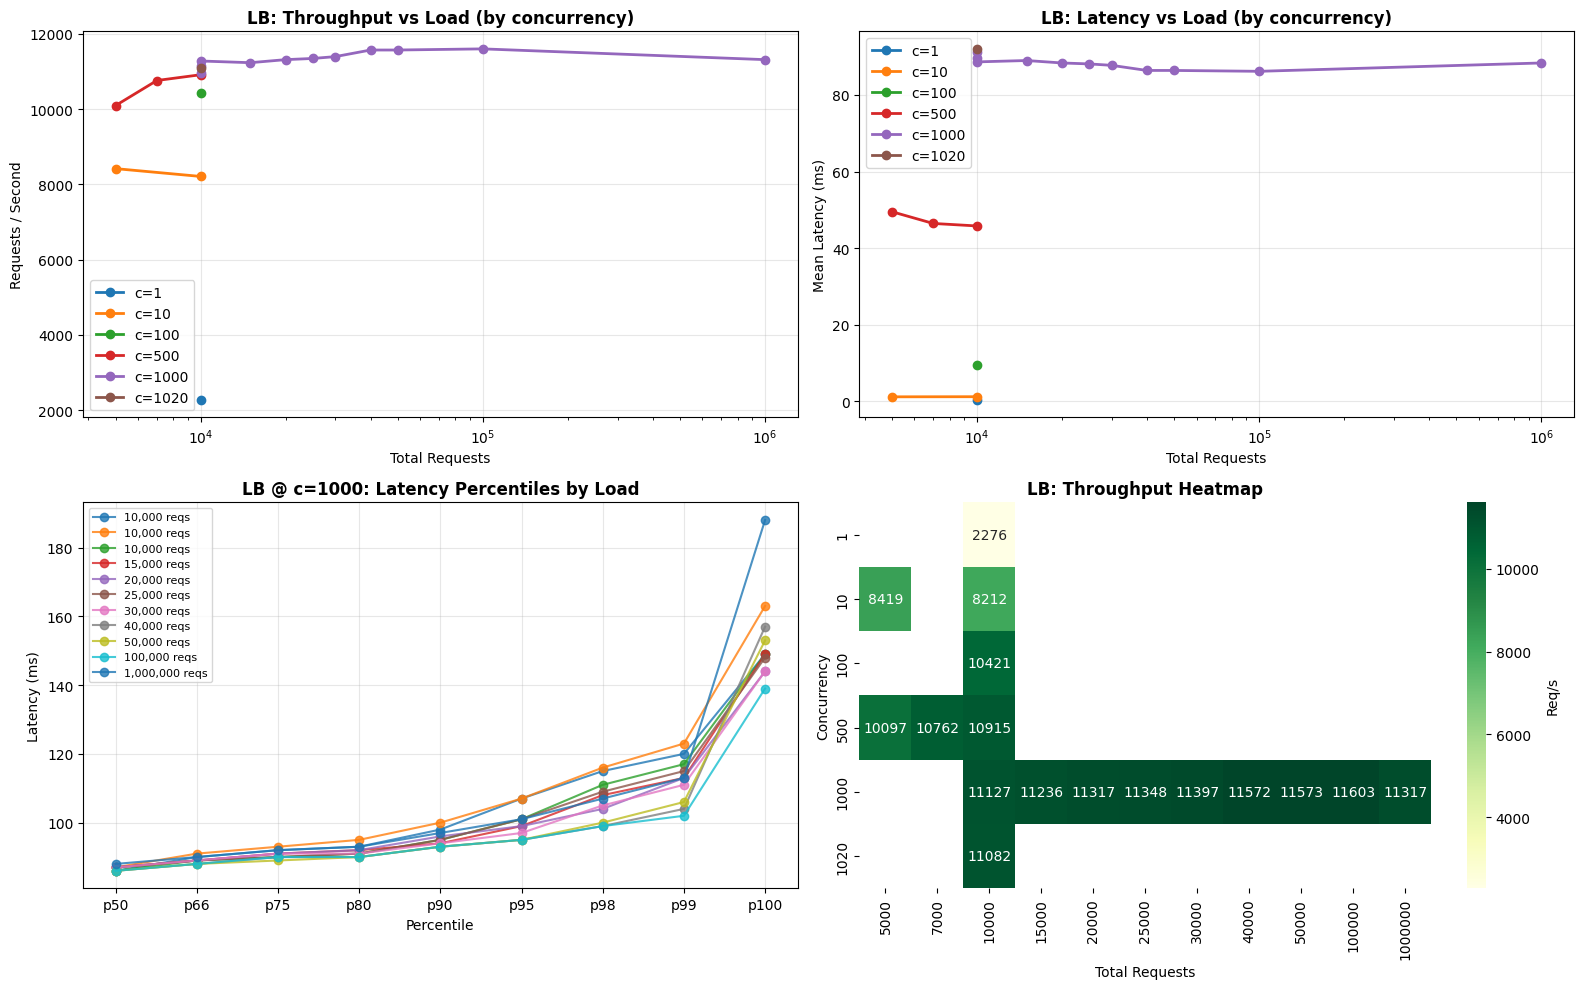

In [32]:
# LB scalability deep dive
lb_success = df_success[df_success['tag'] == 'lb'].sort_values('total_requests')

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

# Top-left: RPS vs total requests (grouped by concurrency)
for conc in sorted(lb_success['concurrency'].unique()):
    subset = lb_success[lb_success['concurrency'] == conc]
    axes[0, 0].plot(subset['total_requests'], subset['requests_per_second'], 
                     marker='o', linewidth=2, label=f'c={conc}')
axes[0, 0].set_xlabel('Total Requests')
axes[0, 0].set_ylabel('Requests / Second')
axes[0, 0].set_title('LB: Throughput vs Load (by concurrency)', fontsize=12, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xscale('log')

# Top-right: mean latency vs total requests
for conc in sorted(lb_success['concurrency'].unique()):
    subset = lb_success[lb_success['concurrency'] == conc]
    axes[0, 1].plot(subset['total_requests'], subset['time_per_request_mean_ms'],
                     marker='o', linewidth=2, label=f'c={conc}')
axes[0, 1].set_xlabel('Total Requests')
axes[0, 1].set_ylabel('Mean Latency (ms)')
axes[0, 1].set_title('LB: Latency vs Load (by concurrency)', fontsize=12, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xscale('log')

# Bottom-left: latency percentiles across LB runs at c=1000
lb_c1000 = lb_success[lb_success['concurrency'] == 1000].sort_values('total_requests')
if len(lb_c1000) > 0:
    for _, row in lb_c1000.iterrows():
        latencies = [row[c] for c in percentile_cols]
        axes[1, 0].plot(percentile_labels, latencies, marker='o', linewidth=1.5,
                         label=f'{row["total_requests"]:,.0f} reqs', alpha=0.8)
    axes[1, 0].set_xlabel('Percentile')
    axes[1, 0].set_ylabel('Latency (ms)')
    axes[1, 0].set_title('LB @ c=1000: Latency Percentiles by Load', fontsize=12, fontweight='bold')
    axes[1, 0].legend(fontsize=8)
    axes[1, 0].grid(True, alpha=0.3)

# Bottom-right: heatmap of throughput by concurrency and request count
lb_pivot = lb_success.pivot_table(values='requests_per_second', 
                                   index='concurrency', columns='total_requests', aggfunc='mean')
if lb_pivot.shape[0] > 1 or lb_pivot.shape[1] > 1:
    sns.heatmap(lb_pivot, annot=True, fmt='.0f', cmap='YlGn', ax=axes[1, 1],
                cbar_kws={'label': 'Req/s'})
    axes[1, 1].set_title('LB: Throughput Heatmap', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('Total Requests')
    axes[1, 1].set_ylabel('Concurrency')
else:
    axes[1, 1].text(0.5, 0.5, 'Not enough data\nfor heatmap', ha='center', va='center', fontsize=14)
    axes[1, 1].set_title('LB: Throughput Heatmap', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

## 8. Head-to-Head Radar Chart
Normalized comparison across key metrics (higher is better for all axes).

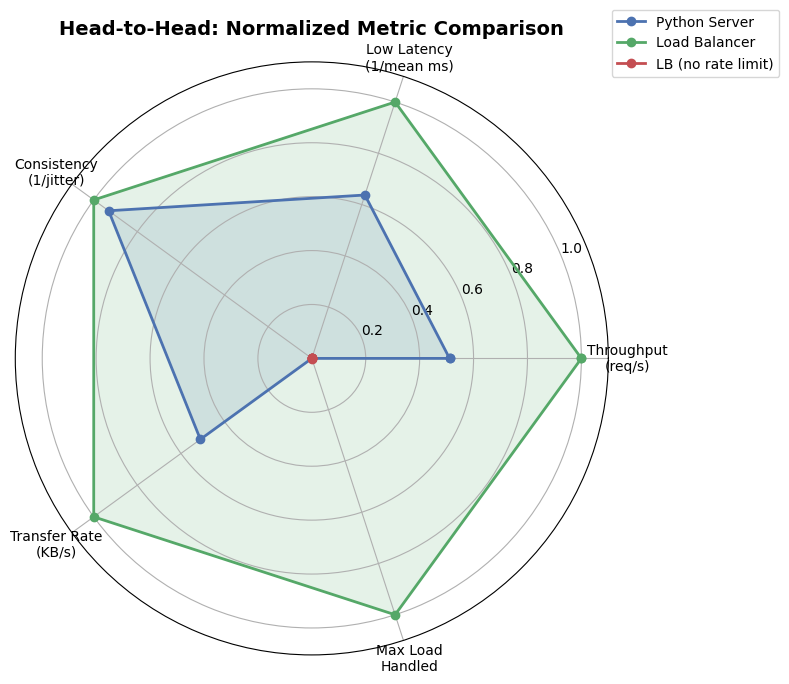


Raw Metric Values:
Metric                   Python Server       Load Balancer       LB (no rate limit)  
--------------------------------------------------------------------------------
Throughput (req/s)       6052.37             10364.72            1546.06             
Low Latency (1/mean ms)  0.01                0.02                0.00                
Consistency (1/jitter)   0.02                0.02                0.00                
Transfer Rate (KB/s)     13937.01            23867.19            3560.18             
Max Load Handled         6500.00             1000000.00          10000.00            


In [33]:
# Radar chart — normalized metrics comparison
from matplotlib.patches import FancyBboxPatch

tags_ordered = ['py', 'lb', 'lbwrl']
metrics = {
    'Throughput\n(req/s)': lambda t: df_success[df_success['tag'] == t]['requests_per_second'].mean(),
    'Low Latency\n(1/mean ms)': lambda t: 1.0 / max(df_success[df_success['tag'] == t]['time_per_request_mean_ms'].mean(), 0.001),
    'Consistency\n(1/jitter)': lambda t: 1.0 / max((df_success[df_success['tag'] == t]['p100_ms'] - df_success[df_success['tag'] == t]['p50_ms']).mean(), 0.001),
    'Transfer Rate\n(KB/s)': lambda t: df_success[df_success['tag'] == t]['transfer_rate_kbps'].mean(),
    'Max Load\nHandled': lambda t: df_success[df_success['tag'] == t]['total_requests'].max(),
}

# Compute raw values, replacing NaN with 0
raw = {}
for tag in tags_ordered:
    vals = []
    for fn in metrics.values():
        v = fn(tag)
        vals.append(v if pd.notna(v) else 0.0)
    raw[tag] = vals

# Normalize to 0-1 per metric
metric_names = list(metrics.keys())
n_metrics = len(metric_names)
norm = {tag: [] for tag in tags_ordered}
for i in range(n_metrics):
    vals = [raw[tag][i] for tag in tags_ordered]
    vmin, vmax = min(vals), max(vals)
    for tag in tags_ordered:
        norm[tag].append((raw[tag][i] - vmin) / (vmax - vmin) if vmax > vmin else 0.5)

# Radar
angles = np.linspace(0, 2 * np.pi, n_metrics, endpoint=False).tolist()
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))
for tag in tags_ordered:
    values = norm[tag] + norm[tag][:1]
    ax.plot(angles, values, 'o-', linewidth=2, label=tag_labels[tag], color=palette[tag])
    ax.fill(angles, values, alpha=0.15, color=palette[tag])

ax.set_xticks(angles[:-1])
ax.set_xticklabels(metric_names, fontsize=10)
ax.set_ylim(0, 1.1)
ax.set_title('Head-to-Head: Normalized Metric Comparison', fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.tight_layout()
plt.show()

# Print raw values table
print("\nRaw Metric Values:")
print("=" * 80)
print(f"{'Metric':<25}", end="")
for tag in tags_ordered:
    print(f"{tag_labels[tag]:<20}", end="")
print()
print("-" * 80)
for i, name in enumerate(metric_names):
    clean_name = name.replace('\n', ' ')
    print(f"{clean_name:<25}", end="")
    for tag in tags_ordered:
        print(f"{raw[tag][i]:<20.2f}", end="")
    print()

## 9. Summary & Key Findings

In [34]:
# Final summary table
print("=" * 90)
print("BENCHMARK SUMMARY".center(90))
print("=" * 90)

for tag in ['py', 'lb', 'lbwrl']:
    subset_all = df[df['tag'] == tag]
    subset_ok = df_success[df_success['tag'] == tag]
    n_total = len(subset_all)
    n_ok = len(subset_ok)
    
    print(f"\n{'─' * 90}")
    print(f"  {tag_labels[tag]} ({tag})")
    print(f"{'─' * 90}")
    print(f"  Runs: {n_ok}/{n_total} successful ({n_ok/n_total*100:.0f}%)")
    
    if n_ok > 0:
        print(f"  Max load handled:     {subset_ok['total_requests'].max():>10,} requests")
        print(f"  Max concurrency:      {subset_ok['concurrency'].max():>10,}")
        print(f"  Avg throughput:       {subset_ok['requests_per_second'].mean():>10,.1f} req/s")
        print(f"  Peak throughput:      {subset_ok['requests_per_second'].max():>10,.1f} req/s")
        print(f"  Avg mean latency:    {subset_ok['time_per_request_mean_ms'].mean():>10,.2f} ms")
        print(f"  Avg p50 latency:     {subset_ok['p50_ms'].mean():>10,.1f} ms")
        print(f"  Avg p99 latency:     {subset_ok['p99_ms'].mean():>10,.1f} ms")
        print(f"  Avg p100 latency:    {subset_ok['p100_ms'].mean():>10,.1f} ms")
        print(f"  Avg transfer rate:   {subset_ok['transfer_rate_kbps'].mean():>10,.1f} KB/s")

# Speedup comparison
py_rps = df_success[df_success['tag'] == 'py']['requests_per_second'].mean()
lb_rps = df_success[df_success['tag'] == 'lb']['requests_per_second'].mean()
lbwrl_rps = df_success[df_success['tag'] == 'lbwrl']['requests_per_second'].mean()

print(f"\n{'=' * 90}")
print(f"  SPEEDUP vs Python Server:")
print(f"    Load Balancer:              {lb_rps/py_rps:.2f}x")
print(f"    LB (no rate limit):         {lbwrl_rps/py_rps:.2f}x")
print(f"{'=' * 90}")

                                    BENCHMARK SUMMARY                                     

──────────────────────────────────────────────────────────────────────────────────────────
  Python Server (py)
──────────────────────────────────────────────────────────────────────────────────────────
  Runs: 9/18 successful (50%)
  Max load handled:          6,500 requests
  Max concurrency:           1,020
  Avg throughput:          6,052.4 req/s
  Peak throughput:         6,421.7 req/s
  Avg mean latency:         99.05 ms
  Avg p50 latency:            1.0 ms
  Avg p99 latency:            1.0 ms
  Avg p100 latency:          55.3 ms
  Avg transfer rate:     13,937.0 KB/s

──────────────────────────────────────────────────────────────────────────────────────────
  Load Balancer (lb)
──────────────────────────────────────────────────────────────────────────────────────────
  Runs: 19/25 successful (76%)
  Max load handled:      1,000,000 requests
  Max concurrency:           1,020
  Avg through